# Stage 6B — PhoBERT Noisy Evaluation on Kaggle GPU

Notebook này dùng trực tiếp output của Stage 3:

```text
/kaggle/input/notebooks/thanhhainguyn/stage-3-phobert-clean-fine-tuning/stage3_phobert_outputs.zip
```

Không cần upload dataset. Notebook sẽ:

1. Extract model PhoBERT từ `stage3_phobert_outputs.zip`.
2. Tải test split UIT-VSFC từ Hugging Face parquet.
3. Tái tạo noisy test sets bằng rule Stage 4.
4. Evaluate PhoBERT sentiment/topic trên clean + noisy.
5. Xuất kết quả Stage 6B.

Yêu cầu Kaggle:

```text
Accelerator: GPU
Internet: On
Input: output notebook Stage 3 chứa stage3_phobert_outputs.zip
```


## 1. Install safe Hugging Face stack

In [1]:
# Kaggle may preinstall PEFT. This project does not use PEFT/LoRA.
# Uninstalling PEFT avoids optional dependency conflicts with the selected HF stack.

!pip uninstall -y peft

!pip install --quiet --upgrade --force-reinstall --no-cache-dir --no-deps \
    "huggingface-hub==0.36.2" \
    "transformers==4.44.2" \
    "tokenizers==0.19.1" \
    "accelerate==0.33.0" \
    "sentencepiece==0.2.0"

print("HF stack installation finished.")


Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 179.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 302.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 377.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 404.1 MB/s eta 0:00:00
HF stack installation finished.


## 2. Imports and environment check

In [2]:
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass
import json
import zipfile
import shutil
import random
import unicodedata
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, classification_report, f1_score

from huggingface_hub import list_repo_files, hf_hub_download
from transformers import AutoModelForSequenceClassification, AutoTokenizer

import transformers
import huggingface_hub

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("Working dir:", Path.cwd())

assert torch.cuda.is_available(), "Please enable Kaggle GPU before running this notebook."
assert transformers.__version__ == "4.44.2", "Unexpected transformers version."
assert huggingface_hub.__version__.startswith("0.36."), "Unexpected huggingface_hub version."


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4
transformers: 4.44.2
huggingface_hub: 0.36.2
Working dir: /kaggle/working


## 3. Extract Stage 3 PhoBERT models

In [3]:
WORK_DIR = Path("/kaggle/working")
STAGE3_EXTRACT_DIR = WORK_DIR / "stage3_phobert_outputs_extracted"

# Search for Stage 3 output zip from Kaggle notebook input.
stage3_zip_candidates = list(Path("/kaggle/input").rglob("stage3_phobert_outputs.zip"))

print("Stage 3 zip candidates:")
for path in stage3_zip_candidates:
    print("-", path)

if not stage3_zip_candidates:
    raise FileNotFoundError(
        "Cannot find stage3_phobert_outputs.zip under /kaggle/input. "
        "Add the output files of your Stage 3 Kaggle notebook as input."
    )

STAGE3_ZIP = stage3_zip_candidates[0]

if STAGE3_EXTRACT_DIR.exists():
    shutil.rmtree(STAGE3_EXTRACT_DIR)

STAGE3_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(STAGE3_ZIP, "r") as z:
    z.extractall(STAGE3_EXTRACT_DIR)

sentiment_candidates = list(STAGE3_EXTRACT_DIR.rglob("models/phobert/sentiment/best_model"))
topic_candidates = list(STAGE3_EXTRACT_DIR.rglob("models/phobert/topic/best_model"))

if not sentiment_candidates:
    raise FileNotFoundError("Cannot find models/phobert/sentiment/best_model in Stage 3 zip.")

if not topic_candidates:
    raise FileNotFoundError("Cannot find models/phobert/topic/best_model in Stage 3 zip.")

SENTIMENT_MODEL_DIR = sentiment_candidates[0]
TOPIC_MODEL_DIR = topic_candidates[0]

# Path that contains the `models/` folder.
MODEL_ROOT = SENTIMENT_MODEL_DIR.parents[3]

print("Using Stage 3 zip:", STAGE3_ZIP)
print("Extracted to:", STAGE3_EXTRACT_DIR)
print("MODEL_ROOT:", MODEL_ROOT)
print("SENTIMENT_MODEL_DIR:", SENTIMENT_MODEL_DIR)
print("TOPIC_MODEL_DIR:", TOPIC_MODEL_DIR)

for path in [SENTIMENT_MODEL_DIR, TOPIC_MODEL_DIR]:
    print("\nModel files in:", path)
    for item in sorted(path.iterdir()):
        print("-", item.name)


Stage 3 zip candidates:
- /kaggle/input/notebooks/thanhhainguyn/stage-3-phobert-clean-fine-tuning/stage3_phobert_outputs.zip
Using Stage 3 zip: /kaggle/input/notebooks/thanhhainguyn/stage-3-phobert-clean-fine-tuning/stage3_phobert_outputs.zip
Extracted to: /kaggle/working/stage3_phobert_outputs_extracted
MODEL_ROOT: /kaggle/working/stage3_phobert_outputs_extracted
SENTIMENT_MODEL_DIR: /kaggle/working/stage3_phobert_outputs_extracted/models/phobert/sentiment/best_model
TOPIC_MODEL_DIR: /kaggle/working/stage3_phobert_outputs_extracted/models/phobert/topic/best_model

Model files in: /kaggle/working/stage3_phobert_outputs_extracted/models/phobert/sentiment/best_model
- added_tokens.json
- bpe.codes
- config.json
- model.safetensors
- special_tokens_map.json
- tokenizer_config.json
- training_args.bin
- vocab.txt

Model files in: /kaggle/working/stage3_phobert_outputs_extracted/models/phobert/topic/best_model
- added_tokens.json
- bpe.codes
- config.json
- model.safetensors
- special_token

## 4. Stage 4 noise generation functions

In [4]:
@dataclass
class TokenItem:
    token: str
    orig_indices: list[int]


def remove_vietnamese_accents(text: str) -> str:
    normalized = unicodedata.normalize("NFD", str(text))
    without_marks = "".join(
        char for char in normalized
        if unicodedata.category(char) != "Mn"
    )
    without_marks = without_marks.replace("đ", "d").replace("Đ", "D")
    return unicodedata.normalize("NFC", without_marks)


def split_token_affixes(token: str) -> tuple[str, str, str]:
    if not token:
        return "", "", ""

    start = 0
    while start < len(token) and not token[start].isalnum():
        start += 1

    end = len(token)
    while end > start and not token[end - 1].isalnum():
        end -= 1

    return token[:start], token[start:end], token[end:]


def normalize_token_for_match(token: str) -> str:
    _, core, _ = split_token_affixes(token)
    return core.lower()


def make_items(text: str) -> list[TokenItem]:
    return [
        TokenItem(token=token, orig_indices=[idx])
        for idx, token in enumerate(str(text).split())
    ]


def items_to_text(items) -> str:
    return " ".join(item.token for item in items)


def span_from_items(items: list[TokenItem], start: int, end: int, replacement: str, rule: str) -> dict:
    affected = []
    for item in items[start:end]:
        affected.extend(item.orig_indices)

    original = " ".join(item.token for item in items[start:end])

    return {
        "start_token": min(affected),
        "end_token": max(affected) + 1,
        "original": original,
        "replacement": replacement,
        "rule": rule,
    }


def make_replacement_token(original_items: list[TokenItem], replacement: str) -> str:
    first_prefix, _, _ = split_token_affixes(original_items[0].token)
    _, _, last_suffix = split_token_affixes(original_items[-1].token)
    return f"{first_prefix}{replacement}{last_suffix}"


def apply_phrase_replacements(
    items: list[TokenItem],
    replacements: dict,
    rule: str,
    rng: random.Random,
    max_replacements: int = 2,
) -> tuple[list[TokenItem], list[dict]]:
    if not replacements:
        return items, []

    phrase_entries = []
    for phrase, replacement in replacements.items():
        phrase_tokens = str(phrase).lower().split()
        phrase_entries.append((phrase_tokens, replacement))

    phrase_entries.sort(key=lambda item: len(item[0]), reverse=True)

    new_items = []
    spans = []

    idx = 0
    replacement_count = 0

    while idx < len(items):
        matched = False

        if replacement_count < max_replacements:
            for phrase_tokens, replacement_value in phrase_entries:
                phrase_len = len(phrase_tokens)
                window = items[idx: idx + phrase_len]

                if len(window) != phrase_len:
                    continue

                window_tokens = [normalize_token_for_match(item.token) for item in window]

                if window_tokens != phrase_tokens:
                    continue

                if isinstance(replacement_value, list):
                    replacement = rng.choice(replacement_value)
                else:
                    replacement = str(replacement_value)

                replacement_token = make_replacement_token(window, replacement)

                orig_indices = []
                for item in window:
                    orig_indices.extend(item.orig_indices)

                spans.append(
                    span_from_items(
                        items=items,
                        start=idx,
                        end=idx + phrase_len,
                        replacement=replacement_token,
                        rule=rule,
                    )
                )

                new_items.append(TokenItem(token=replacement_token, orig_indices=orig_indices))

                idx += phrase_len
                replacement_count += 1
                matched = True
                break

        if not matched:
            new_items.append(items[idx])
            idx += 1

    return new_items, spans


def apply_no_accent_to_items(items: list[TokenItem]) -> tuple[list[TokenItem], list[dict]]:
    new_items = []
    spans = []

    for idx, item in enumerate(items):
        replacement = remove_vietnamese_accents(item.token)

        if replacement != item.token:
            spans.append(
                span_from_items(
                    items=items,
                    start=idx,
                    end=idx + 1,
                    replacement=replacement,
                    rule="no_accent",
                )
            )
            new_items.append(TokenItem(token=replacement, orig_indices=item.orig_indices))
        else:
            new_items.append(item)

    return new_items, spans


def token_has_diacritic(token: str) -> bool:
    _, core, _ = split_token_affixes(token)
    return remove_vietnamese_accents(core) != core


def remove_one_diacritic_from_token(token: str) -> str:
    prefix, core, suffix = split_token_affixes(token)

    for char in core:
        no_accent = remove_vietnamese_accents(char)
        if no_accent != char:
            return prefix + core.replace(char, no_accent, 1) + suffix

    return token


def swap_adjacent_chars(token: str) -> str:
    prefix, core, suffix = split_token_affixes(token)

    if len(core) < 4:
        return token

    chars = list(core)
    swap_idx = min(2, len(chars) - 2)
    chars[swap_idx], chars[swap_idx + 1] = chars[swap_idx + 1], chars[swap_idx]

    return prefix + "".join(chars) + suffix


def apply_typo_to_items(
    items: list[TokenItem],
    rng: random.Random,
    max_typos: int = 1,
    min_token_length: int = 4,
    prefer_diacritic_typo: bool = True,
) -> tuple[list[TokenItem], list[dict]]:
    new_items = [TokenItem(token=item.token, orig_indices=item.orig_indices) for item in items]
    spans = []

    candidate_indices = []
    for idx, item in enumerate(items):
        _, core, _ = split_token_affixes(item.token)
        if len(core) >= min_token_length and not core.isnumeric():
            candidate_indices.append(idx)

    if not candidate_indices:
        return new_items, spans

    if prefer_diacritic_typo:
        diacritic_candidates = [
            idx for idx in candidate_indices
            if token_has_diacritic(items[idx].token)
        ]
        if diacritic_candidates:
            candidate_indices = diacritic_candidates

    rng.shuffle(candidate_indices)

    changed = 0
    for idx in candidate_indices:
        original_token = new_items[idx].token

        if token_has_diacritic(original_token):
            replacement = remove_one_diacritic_from_token(original_token)
        else:
            replacement = swap_adjacent_chars(original_token)

        if replacement == original_token:
            continue

        spans.append(
            span_from_items(
                items=items,
                start=idx,
                end=idx + 1,
                replacement=replacement,
                rule="typo",
            )
        )

        new_items[idx] = TokenItem(token=replacement, orig_indices=new_items[idx].orig_indices)

        changed += 1
        if changed >= max_typos:
            break

    return new_items, spans


def elongate_token(token: str, repeat_count: int = 2) -> str:
    prefix, core, suffix = split_token_affixes(token)

    if not core:
        return token

    return prefix + core + (core[-1] * repeat_count) + suffix


def apply_elongation_to_items(
    items: list[TokenItem],
    rng: random.Random,
    max_elongations: int = 1,
    min_token_length: int = 3,
    repeat_count: int = 2,
) -> tuple[list[TokenItem], list[dict]]:
    new_items = [TokenItem(token=item.token, orig_indices=item.orig_indices) for item in items]
    spans = []

    candidate_indices = []
    for idx, item in enumerate(items):
        _, core, _ = split_token_affixes(item.token)
        if len(core) >= min_token_length and not core.isnumeric():
            candidate_indices.append(idx)

    if not candidate_indices:
        return new_items, spans

    rng.shuffle(candidate_indices)

    changed = 0
    for idx in candidate_indices:
        original_token = new_items[idx].token
        replacement = elongate_token(original_token, repeat_count=repeat_count)

        if replacement == original_token:
            continue

        spans.append(
            span_from_items(
                items=items,
                start=idx,
                end=idx + 1,
                replacement=replacement,
                rule="elongation",
            )
        )

        new_items[idx] = TokenItem(token=replacement, orig_indices=new_items[idx].orig_indices)

        changed += 1
        if changed >= max_elongations:
            break

    return new_items, spans


def changed_token_ratio(original_text: str, changed_spans: list[dict]) -> float:
    total_tokens = len(str(original_text).split())

    if total_tokens == 0:
        return 0.0

    changed_indices = set()
    for span in changed_spans:
        for idx in range(int(span["start_token"]), int(span["end_token"])):
            changed_indices.add(idx)

    return len(changed_indices) / total_tokens


def severity_from_ratio(ratio: float, low_max_ratio: float = 0.20, medium_max_ratio: float = 0.40) -> str:
    if ratio == 0:
        return "none"
    if ratio <= low_max_ratio:
        return "low"
    if ratio <= medium_max_ratio:
        return "medium"
    return "high"


STAGE4_NOISE_CONFIG = {
    "seed": 42,
    "severity": {
        "low_max_ratio": 0.20,
        "medium_max_ratio": 0.40,
    },
    "noise_types": [
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ],
    "domain_abbreviation": {
        "max_replacements_per_sentence": 2,
        "replacements": {
            "giảng viên": "gv",
            "giáo viên": "gv",
            "sinh viên": "sv",
            "học sinh": "hs",
            "học phần": "hp",
            "môn học": "mh",
            "bài tập": "bt",
            "bài kiểm tra": "bkt",
            "kiểm tra": "kt",
            "thực hành": "th",
            "lý thuyết": "lt",
            "cơ sở vật chất": "csvc",
            "phòng học": "ph",
            "phòng máy": "pm",
            "chương trình đào tạo": "ctdt",
        },
    },
    "teencode_colloquial": {
        "max_replacements_per_sentence": 2,
        "replacements": {
            "không": ["ko", "k"],
            "được": ["dc", "đc"],
            "luôn": ["lun"],
            "rất": ["r"],
            "nhiều": ["nhìu"],
            "với": ["vs"],
            "biết": ["bít"],
        },
    },
    "typo": {
        "max_typos_per_sentence": 1,
        "prefer_diacritic_typo": True,
        "min_token_length": 4,
    },
    "elongation": {
        "max_elongations_per_sentence": 1,
        "min_token_length": 3,
        "repeat_count": 2,
    },
    "mixed_noise": {
        "max_noise_types_per_sentence": 3,
        "max_changed_token_ratio": 0.40,
        "mixed_no_accent": False,
        "char_noise_choice": {
            "typo": 0.5,
            "elongation": 0.5,
        },
        "apply_order": [
            "domain_abbreviation",
            "teencode_colloquial",
            "char_noise",
            "no_accent",
        ],
    },
}


def apply_noise(text: str, noise_type: str, config: dict, rng: random.Random) -> tuple[str, list[dict]]:
    items = make_items(text)

    if noise_type == "no_accent":
        new_items, spans = apply_no_accent_to_items(items)
        return items_to_text(new_items), spans

    if noise_type == "domain_abbreviation":
        domain_config = config["domain_abbreviation"]
        new_items, spans = apply_phrase_replacements(
            items=items,
            replacements=domain_config["replacements"],
            rule="domain_abbreviation",
            rng=rng,
            max_replacements=int(domain_config.get("max_replacements_per_sentence", 2)),
        )
        return items_to_text(new_items), spans

    if noise_type == "teencode_colloquial":
        teencode_config = config["teencode_colloquial"]
        new_items, spans = apply_phrase_replacements(
            items=items,
            replacements=teencode_config["replacements"],
            rule="teencode_colloquial",
            rng=rng,
            max_replacements=int(teencode_config.get("max_replacements_per_sentence", 2)),
        )
        return items_to_text(new_items), spans

    if noise_type == "typo":
        typo_config = config["typo"]
        new_items, spans = apply_typo_to_items(
            items=items,
            rng=rng,
            max_typos=int(typo_config.get("max_typos_per_sentence", 1)),
            min_token_length=int(typo_config.get("min_token_length", 4)),
            prefer_diacritic_typo=bool(typo_config.get("prefer_diacritic_typo", True)),
        )
        return items_to_text(new_items), spans

    if noise_type == "elongation":
        elongation_config = config["elongation"]
        new_items, spans = apply_elongation_to_items(
            items=items,
            rng=rng,
            max_elongations=int(elongation_config.get("max_elongations_per_sentence", 1)),
            min_token_length=int(elongation_config.get("min_token_length", 3)),
            repeat_count=int(elongation_config.get("repeat_count", 2)),
        )
        return items_to_text(new_items), spans

    if noise_type == "mixed_noise":
        return apply_mixed_noise(text=text, config=config, rng=rng)

    raise ValueError(f"Unsupported noise type: {noise_type}")


def apply_mixed_noise(text: str, config: dict, rng: random.Random) -> tuple[str, list[dict]]:
    mixed_config = config["mixed_noise"]
    apply_order = mixed_config.get("apply_order", [])

    items = make_items(text)
    all_spans = []

    applied_count = 0
    max_noise_types = int(mixed_config.get("max_noise_types_per_sentence", 3))

    for step in apply_order:
        if applied_count >= max_noise_types:
            break

        before_text = items_to_text(items)

        if step == "domain_abbreviation":
            domain_config = config["domain_abbreviation"]
            items, spans = apply_phrase_replacements(
                items=items,
                replacements=domain_config["replacements"],
                rule="domain_abbreviation",
                rng=rng,
                max_replacements=1,
            )

        elif step == "teencode_colloquial":
            teencode_config = config["teencode_colloquial"]
            items, spans = apply_phrase_replacements(
                items=items,
                replacements=teencode_config["replacements"],
                rule="teencode_colloquial",
                rng=rng,
                max_replacements=1,
            )

        elif step == "char_noise":
            char_choice = mixed_config.get("char_noise_choice", {"typo": 0.5, "elongation": 0.5})
            selected = rng.choices(
                ["typo", "elongation"],
                weights=[float(char_choice.get("typo", 0.5)), float(char_choice.get("elongation", 0.5))],
                k=1,
            )[0]

            if selected == "typo":
                typo_config = config["typo"]
                items, spans = apply_typo_to_items(
                    items=items,
                    rng=rng,
                    max_typos=1,
                    min_token_length=int(typo_config.get("min_token_length", 4)),
                    prefer_diacritic_typo=bool(typo_config.get("prefer_diacritic_typo", True)),
                )
            else:
                elongation_config = config["elongation"]
                items, spans = apply_elongation_to_items(
                    items=items,
                    rng=rng,
                    max_elongations=1,
                    min_token_length=int(elongation_config.get("min_token_length", 3)),
                    repeat_count=int(elongation_config.get("repeat_count", 2)),
                )

        elif step == "no_accent":
            if not bool(mixed_config.get("mixed_no_accent", False)):
                spans = []
            else:
                items, spans = apply_no_accent_to_items(items)

        else:
            spans = []

        after_text = items_to_text(items)

        if spans and after_text != before_text:
            all_spans.extend(spans)
            applied_count += 1

    return items_to_text(items), all_spans


def generate_noisy_dataset(df: pd.DataFrame, noise_type: str, config: dict, subword_counter) -> pd.DataFrame:
    seed = int(config.get("seed", 42))
    rng = random.Random(seed + sum(ord(char) for char in noise_type))

    rows = []

    low_max = float(config.get("severity", {}).get("low_max_ratio", 0.20))
    medium_max = float(config.get("severity", {}).get("medium_max_ratio", 0.40))
    max_changed_ratio = float(config.get("mixed_noise", {}).get("max_changed_token_ratio", 0.40))

    for _, row in df.iterrows():
        original_text = str(row["text"])
        noisy_text, spans = apply_noise(original_text, noise_type, config, rng)

        ratio = changed_token_ratio(original_text, spans)
        severity = severity_from_ratio(ratio, low_max, medium_max)

        rows.append({
            "id": row["id"],
            "original_text": original_text,
            "noisy_text": noisy_text,
            "sentiment_label": row["sentiment_label"],
            "topic_label": row["topic_label"],
            "noise_type": noise_type,
            "severity": severity,
            "changed_token_ratio": ratio,
            "changed_spans": json.dumps(spans, ensure_ascii=False),
            "num_words_clean": len(original_text.split()),
            "num_words_noisy": len(noisy_text.split()),
            "num_subwords_clean": subword_counter(original_text),
            "num_subwords_noisy": subword_counter(noisy_text),
            "is_changed": noisy_text != original_text,
            "exceeds_max_changed_token_ratio": (
                ratio > max_changed_ratio if noise_type == "mixed_noise" else False
            ),
        })

    return pd.DataFrame(rows)


print("Stage 4 noise functions loaded.")
print("Noise types:", STAGE4_NOISE_CONFIG["noise_types"])
print("mixed_no_accent:", STAGE4_NOISE_CONFIG["mixed_noise"]["mixed_no_accent"])


Stage 4 noise functions loaded.
Noise types: ['no_accent', 'domain_abbreviation', 'teencode_colloquial', 'typo', 'elongation', 'mixed_noise']
mixed_no_accent: False


## 5. Prepare clean test and regenerate noisy test sets

In [5]:
DATASET_NAME = "uitnlp/vietnamese_students_feedback"
PARQUET_REVISION = "refs/convert/parquet"

WORKSPACE = WORK_DIR / "stage6b_workspace"
DATA_PROCESSED_DIR = WORKSPACE / "data/processed"
DATA_NOISY_DIR = WORKSPACE / "data/noisy"
CONFIGS_DIR = WORKSPACE / "configs"

for path in [DATA_PROCESSED_DIR, DATA_NOISY_DIR, CONFIGS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Download test parquet from Hugging Face converted parquet export.
# ---------------------------------------------------------------------
repo_files = list_repo_files(
    repo_id=DATASET_NAME,
    repo_type="dataset",
    revision=PARQUET_REVISION,
)

parquet_files = [file for file in repo_files if file.endswith(".parquet")]
test_parquet_files = [file for file in parquet_files if "test" in file.lower()]

print("Test parquet files:")
for file in test_parquet_files:
    print("-", file)

if not test_parquet_files:
    raise FileNotFoundError("No test parquet file found in Hugging Face converted parquet export.")

test_parts = []

for parquet_file in test_parquet_files:
    local_path = hf_hub_download(
        repo_id=DATASET_NAME,
        filename=parquet_file,
        repo_type="dataset",
        revision=PARQUET_REVISION,
    )
    test_parts.append(pd.read_parquet(local_path))

raw_test_df = pd.concat(test_parts, ignore_index=True)

print("Raw test shape:", raw_test_df.shape)
print("Raw test columns:", raw_test_df.columns.tolist())
display(raw_test_df.head())

# ---------------------------------------------------------------------
# 2. Create Stage 1 compatible test.csv.
# ---------------------------------------------------------------------
label_mapping = {
    "dataset_name": DATASET_NAME,
    "sentiment": {
        "source_column": "sentiment",
        "verified_from_hf_features": True,
        "id_to_name": {
            "0": "negative",
            "1": "neutral",
            "2": "positive",
        },
    },
    "topic": {
        "source_column": "topic",
        "verified_from_hf_features": True,
        "id_to_name": {
            "0": "lecturer",
            "1": "training_program",
            "2": "facility",
            "3": "others",
        },
    },
}

def map_label(value, id_to_name):
    value_key = str(value)
    if value_key in id_to_name:
        return id_to_name[value_key]
    return value_key.lower()

required_raw_columns = ["sentence", "sentiment", "topic"]
missing_raw_columns = [col for col in required_raw_columns if col not in raw_test_df.columns]

if missing_raw_columns:
    raise KeyError(f"Missing raw test columns: {missing_raw_columns}")

test_df = pd.DataFrame()
test_df["id"] = [f"test_{i}" for i in range(len(raw_test_df))]
test_df["split"] = "test"
test_df["text"] = raw_test_df["sentence"].astype(str).str.strip()

test_df["sentiment_label_raw"] = raw_test_df["sentiment"]
test_df["sentiment_label"] = raw_test_df["sentiment"].apply(
    lambda x: map_label(x, label_mapping["sentiment"]["id_to_name"])
)

test_df["topic_label_raw"] = raw_test_df["topic"]
test_df["topic_label"] = raw_test_df["topic"].apply(
    lambda x: map_label(x, label_mapping["topic"]["id_to_name"])
)

test_df["char_count"] = test_df["text"].str.len()
test_df["raw_word_count"] = test_df["text"].str.split().apply(len)

test_path = DATA_PROCESSED_DIR / "test.csv"
test_df.to_csv(test_path, index=False, encoding="utf-8-sig")

with open(CONFIGS_DIR / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

print("Saved clean test:", test_path)
print("Clean test shape:", test_df.shape)
display(test_df.head())

# ---------------------------------------------------------------------
# 3. Regenerate Stage 4 noisy sets.
# ---------------------------------------------------------------------
# Use PhoBERT tokenizer for subword metadata in noisy files.
try:
    subword_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_DIR, use_fast=False)
except Exception:
    subword_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)

def count_subwords(text: str) -> int:
    return len(subword_tokenizer.tokenize(str(text)))

noisy_frames = {}

for noise_type in STAGE4_NOISE_CONFIG["noise_types"]:
    noisy_df = generate_noisy_dataset(
        df=test_df,
        noise_type=noise_type,
        config=STAGE4_NOISE_CONFIG,
        subword_counter=count_subwords,
    )

    output_path = DATA_NOISY_DIR / f"04_test_{noise_type}.csv"
    noisy_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    noisy_frames[noise_type] = noisy_df

    changed_pct = noisy_df["is_changed"].mean() * 100
    mean_ratio = noisy_df["changed_token_ratio"].mean()

    print(f"Saved: {output_path} | shape={noisy_df.shape} | changed={changed_pct:.2f}% | mean_ratio={mean_ratio:.4f}")

print("\nWorkspace:", WORKSPACE)
print("Clean:", DATA_PROCESSED_DIR / "test.csv")
print("Noisy files:")
for path in sorted(DATA_NOISY_DIR.glob("04_test_*.csv")):
    print("-", path.name)


Test parquet files:
- default/test/0000.parquet


default/test/0000.parquet:   0%|          | 0.00/134k [00:00<?, ?B/s]

Raw test shape: (3166, 3)
Raw test columns: ['sentence', 'sentiment', 'topic']


,sentence,sentiment,topic
0,nói tiếng anh lưu loát .,2,0
1,giáo viên rất vui tính .,2,0
2,cô max có tâm .,2,0
3,"giảng bài thu hút , dí dỏm .",2,0
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0


Saved clean test: /kaggle/working/stage6b_workspace/data/processed/test.csv
Clean test shape: (3166, 9)


,id,split,text,sentiment_label_raw,sentiment_label,topic_label_raw,topic_label,char_count,raw_word_count
0,test_0,test,nói tiếng anh lưu loát .,2,positive,0,lecturer,24,6
1,test_1,test,giáo viên rất vui tính .,2,positive,0,lecturer,24,6
2,test_2,test,cô max có tâm .,2,positive,0,lecturer,15,5
3,test_3,test,"giảng bài thu hút , dí dỏm .",2,positive,0,lecturer,28,8
4,test_4,test,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,negative,0,lecturer,79,17


Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_no_accent.csv | shape=(3166, 15) | changed=99.87% | mean_ratio=0.7583
Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_domain_abbreviation.csv | shape=(3166, 15) | changed=48.33% | mean_ratio=0.0902
Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_teencode_colloquial.csv | shape=(3166, 15) | changed=48.67% | mean_ratio=0.0484
Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_typo.csv | shape=(3166, 15) | changed=97.09% | mean_ratio=0.0956
Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_elongation.csv | shape=(3166, 15) | changed=99.94% | mean_ratio=0.1019
Saved: /kaggle/working/stage6b_workspace/data/noisy/04_test_mixed_noise.csv | shape=(3166, 15) | changed=99.02% | mean_ratio=0.2089

Workspace: /kaggle/working/stage6b_workspace
Clean: /kaggle/working/stage6b_workspace/data/processed/test.csv
Noisy files:
- 04_test_domain_abbreviation.csv
- 04_test_elongation.csv
- 04_test_mixed_noi

## 6. Evaluation helpers

In [6]:
OUTPUT_ROOT = WORK_DIR / "stage6b_outputs"
TABLES_DIR = OUTPUT_ROOT / "reports/tables"
FIGURES_DIR = OUTPUT_ROOT / "reports/figures"
NOTES_DIR = OUTPUT_ROOT / "reports/notes"

for path in [TABLES_DIR, FIGURES_DIR, NOTES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 128
BATCH_SIZE = 64
INCLUDE_CHANGED_ONLY = True
PHOBERT_FALLBACK_MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

compact_label_mapping = {
    task: {str(k): str(v).lower() for k, v in label_mapping[task]["id_to_name"].items()}
    for task in ["sentiment", "topic"]
}

def get_label_names(task: str):
    return [
        compact_label_mapping[task][key]
        for key in sorted(compact_label_mapping[task].keys(), key=lambda value: int(value))
    ]


def prepare_clean_eval_frame(clean_df: pd.DataFrame, task: str) -> pd.DataFrame:
    label_col = f"{task}_label"

    return pd.DataFrame({
        "id": clean_df["id"],
        "text": clean_df["text"].astype(str),
        "true_label": clean_df[label_col].astype(str).str.lower(),
        "noise_type": "clean",
        "evaluation_scope": "full",
        "is_changed": True,
        "changed_token_ratio": 0.0,
        "severity": "clean",
        "original_text": clean_df["text"].astype(str),
        "noisy_text": clean_df["text"].astype(str),
    })


def prepare_noisy_eval_frame(noisy_df: pd.DataFrame, task: str, evaluation_scope: str) -> pd.DataFrame:
    label_col = f"{task}_label"
    df = noisy_df.copy()

    if evaluation_scope == "changed_only":
        df = df[df["is_changed"].astype(bool)].copy()

    return pd.DataFrame({
        "id": df["id"],
        "text": df["noisy_text"].astype(str),
        "true_label": df[label_col].astype(str).str.lower(),
        "noise_type": df["noise_type"].astype(str),
        "evaluation_scope": evaluation_scope,
        "is_changed": df["is_changed"].astype(bool),
        "changed_token_ratio": df["changed_token_ratio"],
        "severity": df["severity"].astype(str),
        "original_text": df["original_text"].astype(str),
        "noisy_text": df["noisy_text"].astype(str),
    })


def build_eval_frames(task: str):
    frames = [prepare_clean_eval_frame(test_df, task)]

    for noise_type, noisy_df in noisy_frames.items():
        frames.append(prepare_noisy_eval_frame(noisy_df, task, "full"))

        if INCLUDE_CHANGED_ONLY:
            changed_frame = prepare_noisy_eval_frame(noisy_df, task, "changed_only")
            if len(changed_frame) > 0:
                frames.append(changed_frame)

    return frames


def get_model_id2label(model, task: str):
    config_mapping = getattr(model.config, "id2label", None)

    if isinstance(config_mapping, dict):
        normalized = {}
        valid = True

        for key, value in config_mapping.items():
            try:
                key_int = int(key)
            except Exception:
                valid = False
                break

            value_str = str(value).lower()
            if value_str.startswith("label_"):
                valid = False
                break

            normalized[key_int] = value_str

        if valid and normalized:
            return normalized

    return {int(k): v for k, v in compact_label_mapping[task].items()}


def get_model_dir(task: str) -> Path:
    if task == "sentiment":
        return SENTIMENT_MODEL_DIR
    if task == "topic":
        return TOPIC_MODEL_DIR
    raise ValueError(f"Unsupported task: {task}")


def load_phobert_for_task(task: str):
    model_dir = get_model_dir(task)

    if not model_dir.exists():
        raise FileNotFoundError(f"Missing PhoBERT model directory: {model_dir}")

    try:
        tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(PHOBERT_FALLBACK_MODEL_NAME, use_fast=False)

    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(DEVICE)
    model.eval()

    id2label = get_model_id2label(model, task)

    return tokenizer, model, id2label, model_dir


def predict_texts(tokenizer, model, id2label: dict[int, str], texts: list[str]) -> list[str]:
    encodings = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    dataset = TensorDataset(
        encodings["input_ids"],
        encodings["attention_mask"],
    )

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)

    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch[0].to(DEVICE)
            attention_mask = batch[1].to(DEVICE)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred_ids = outputs.logits.argmax(dim=-1).detach().cpu().numpy().tolist()
            predictions.extend([id2label[int(pred_id)] for pred_id in pred_ids])

    return predictions


def compute_summary_metrics(y_true, y_pred, labels):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
    }


def classification_report_rows(y_true, y_pred, labels, task, noise_type, evaluation_scope):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )

    rows = []

    for label_name, metrics in report.items():
        if not isinstance(metrics, dict):
            continue

        rows.append({
            "task": task,
            "model_type": "phobert",
            "model_name": "phobert_base",
            "noise_type": noise_type,
            "evaluation_scope": evaluation_scope,
            "label": label_name,
            "precision": metrics.get("precision"),
            "recall": metrics.get("recall"),
            "f1_score": metrics.get("f1-score"),
            "support": metrics.get("support"),
        })

    return rows


def compute_robustness_drop(results_df: pd.DataFrame) -> pd.DataFrame:
    clean_df = results_df[
        (results_df["noise_type"] == "clean")
        & (results_df["evaluation_scope"] == "full")
    ].copy()

    clean_lookup = {
        (row["task"], row["model_type"], row["model_name"]): row
        for _, row in clean_df.iterrows()
    }

    rows = []

    noisy_df = results_df[results_df["noise_type"] != "clean"].copy()

    for _, row in noisy_df.iterrows():
        key = (row["task"], row["model_type"], row["model_name"])
        clean_row = clean_lookup[key]

        clean_macro_f1 = float(clean_row["macro_f1"])
        noisy_macro_f1 = float(row["macro_f1"])
        absolute_drop = clean_macro_f1 - noisy_macro_f1
        relative_drop_pct = absolute_drop / clean_macro_f1 * 100 if clean_macro_f1 != 0 else 0.0

        rows.append({
            "task": row["task"],
            "model_type": row["model_type"],
            "model_name": row["model_name"],
            "noise_type": row["noise_type"],
            "evaluation_scope": row["evaluation_scope"],
            "clean_macro_f1": clean_macro_f1,
            "noisy_macro_f1": noisy_macro_f1,
            "absolute_macro_f1_drop": absolute_drop,
            "relative_macro_f1_drop_pct": relative_drop_pct,
            "clean_accuracy": float(clean_row["accuracy"]),
            "noisy_accuracy": float(row["accuracy"]),
            "absolute_accuracy_drop": float(clean_row["accuracy"]) - float(row["accuracy"]),
        })

    return pd.DataFrame(rows)


print("Evaluation helpers ready.")
print("BATCH_SIZE:", BATCH_SIZE)
print("INCLUDE_CHANGED_ONLY:", INCLUDE_CHANGED_ONLY)
print("DEVICE:", DEVICE)


Evaluation helpers ready.
BATCH_SIZE: 64
INCLUDE_CHANGED_ONLY: True
DEVICE: cuda


## 7. Evaluate PhoBERT models

In [7]:
summary_rows = []
prediction_frames = []
classification_rows = []

for task in ["sentiment", "topic"]:
    print("\n" + "=" * 100)
    print("Loading PhoBERT task:", task)

    tokenizer, model, id2label, model_dir = load_phobert_for_task(task)
    labels = get_label_names(task)
    eval_frames = build_eval_frames(task)

    print("Model dir:", model_dir)
    print("Labels:", labels)
    print("Number of eval frames:", len(eval_frames))

    for eval_df in eval_frames:
        noise_type = str(eval_df["noise_type"].iloc[0])
        evaluation_scope = str(eval_df["evaluation_scope"].iloc[0])

        print(f"  -> task={task}, noise={noise_type}, scope={evaluation_scope}, rows={len(eval_df)}")

        texts = eval_df["text"].astype(str).tolist()
        y_true = eval_df["true_label"].astype(str).str.lower().tolist()
        y_pred = predict_texts(tokenizer, model, id2label, texts)

        metrics = compute_summary_metrics(y_true, y_pred, labels)

        summary_rows.append({
            "task": task,
            "model_type": "phobert",
            "model_name": "phobert_base",
            "model_path": str(model_dir),
            "noise_type": noise_type,
            "evaluation_scope": evaluation_scope,
            "num_eval_samples": len(eval_df),
            **metrics,
        })

        # Save light predictions only. Text can be joined locally from Stage 4 noisy data when needed.
        pred_df = eval_df[[
            "id",
            "noise_type",
            "evaluation_scope",
            "true_label",
            "is_changed",
            "changed_token_ratio",
            "severity",
        ]].copy()

        pred_df["task"] = task
        pred_df["model_type"] = "phobert"
        pred_df["model_name"] = "phobert_base"
        pred_df["pred_label"] = y_pred
        pred_df["is_correct"] = pred_df["true_label"] == pred_df["pred_label"]

        prediction_frames.append(pred_df)

        classification_rows.extend(
            classification_report_rows(
                y_true=y_true,
                y_pred=y_pred,
                labels=labels,
                task=task,
                noise_type=noise_type,
                evaluation_scope=evaluation_scope,
            )
        )

    del model
    torch.cuda.empty_cache()

phobert_results_df = pd.DataFrame(summary_rows)
phobert_predictions_light_df = pd.concat(prediction_frames, ignore_index=True)
phobert_classification_reports_df = pd.DataFrame(classification_rows)

display(phobert_results_df)
print("Results shape:", phobert_results_df.shape)
print("Predictions light shape:", phobert_predictions_light_df.shape)
print("Classification reports shape:", phobert_classification_reports_df.shape)



Loading PhoBERT task: sentiment
Model dir: /kaggle/working/stage3_phobert_outputs_extracted/models/phobert/sentiment/best_model
Labels: ['negative', 'neutral', 'positive']
Number of eval frames: 13
  -> task=sentiment, noise=clean, scope=full, rows=3166
  -> task=sentiment, noise=no_accent, scope=full, rows=3166
  -> task=sentiment, noise=no_accent, scope=changed_only, rows=3162
  -> task=sentiment, noise=domain_abbreviation, scope=full, rows=3166
  -> task=sentiment, noise=domain_abbreviation, scope=changed_only, rows=1530
  -> task=sentiment, noise=teencode_colloquial, scope=full, rows=3166
  -> task=sentiment, noise=teencode_colloquial, scope=changed_only, rows=1541
  -> task=sentiment, noise=typo, scope=full, rows=3166
  -> task=sentiment, noise=typo, scope=changed_only, rows=3074
  -> task=sentiment, noise=elongation, scope=full, rows=3166
  -> task=sentiment, noise=elongation, scope=changed_only, rows=3164
  -> task=sentiment, noise=mixed_noise, scope=full, rows=3166
  -> task=s

,task,model_type,model_name,model_path,noise_type,evaluation_scope,num_eval_samples,accuracy,macro_f1,weighted_f1
0,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,clean,full,3166,0.932407,0.829471,0.931205
1,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,no_accent,full,3166,0.358812,0.316530,0.400303
2,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,no_accent,changed_only,3162,0.358634,0.316265,0.400295
3,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,domain_abbreviation,full,3166,0.927985,0.825747,0.927699
4,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,domain_abbreviation,changed_only,1530,0.932680,0.822826,0.933888
5,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,teencode_colloquial,full,3166,0.918193,0.805754,0.918444
6,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,teencode_colloquial,changed_only,1541,0.911097,0.754515,0.913168
7,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,typo,full,3166,0.900190,0.784816,0.901491
8,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,typo,changed_only,3074,0.900781,0.777511,0.902408
9,sentiment,phobert,phobert_base,/kaggle/working/stage3_phobert_outputs_extract...,elongation,full,3166,0.918193,0.799470,0.918065


Results shape: (26, 10)
Predictions light shape: (75536, 12)
Classification reports shape: (143, 10)


## 8. Robustness drop and ranking

In [8]:
phobert_drop_df = compute_robustness_drop(phobert_results_df)

phobert_ranking_df = (
    phobert_drop_df[phobert_drop_df["evaluation_scope"] == "full"]
    .groupby(["task", "model_type", "model_name"])
    .agg(
        mean_absolute_macro_f1_drop=("absolute_macro_f1_drop", "mean"),
        max_absolute_macro_f1_drop=("absolute_macro_f1_drop", "max"),
        mean_relative_macro_f1_drop_pct=("relative_macro_f1_drop_pct", "mean"),
    )
    .reset_index()
)

display(phobert_drop_df.head(30))
display(phobert_ranking_df)


,task,model_type,model_name,noise_type,evaluation_scope,clean_macro_f1,noisy_macro_f1,absolute_macro_f1_drop,relative_macro_f1_drop_pct,clean_accuracy,noisy_accuracy,absolute_accuracy_drop
0,sentiment,phobert,phobert_base,no_accent,full,0.829471,0.316530,0.512942,61.839592,0.932407,0.358812,0.573594
1,sentiment,phobert,phobert_base,no_accent,changed_only,0.829471,0.316265,0.513206,61.871513,0.932407,0.358634,0.573773
2,sentiment,phobert,phobert_base,domain_abbreviation,full,0.829471,0.825747,0.003725,0.449032,0.932407,0.927985,0.004422
3,sentiment,phobert,phobert_base,domain_abbreviation,changed_only,0.829471,0.822826,0.006645,0.801082,0.932407,0.932680,-0.000273
4,sentiment,phobert,phobert_base,teencode_colloquial,full,0.829471,0.805754,0.023717,2.859283,0.932407,0.918193,0.014214
5,sentiment,phobert,phobert_base,teencode_colloquial,changed_only,0.829471,0.754515,0.074956,9.036599,0.932407,0.911097,0.021310
6,sentiment,phobert,phobert_base,typo,full,0.829471,0.784816,0.044655,5.383541,0.932407,0.900190,0.032217
7,sentiment,phobert,phobert_base,typo,changed_only,0.829471,0.777511,0.051960,6.264203,0.932407,0.900781,0.031626
8,sentiment,phobert,phobert_base,elongation,full,0.829471,0.799470,0.030001,3.616930,0.932407,0.918193,0.014214
9,sentiment,phobert,phobert_base,elongation,changed_only,0.829471,0.798484,0.030987,3.735749,0.932407,0.918142,0.014265


,task,model_type,model_name,mean_absolute_macro_f1_drop,max_absolute_macro_f1_drop,mean_relative_macro_f1_drop_pct
0,sentiment,phobert,phobert_base,0.112278,0.512942,13.536110
1,topic,phobert,phobert_base,0.129672,0.542183,16.104808


## 9. Save tables and figures

Saved tables:
- /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_noisy_evaluation_all.csv
- /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_predictions_light.csv
- /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_classification_reports_all.csv
- /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_robustness_drop_all.csv
- /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_robustness_ranking.csv


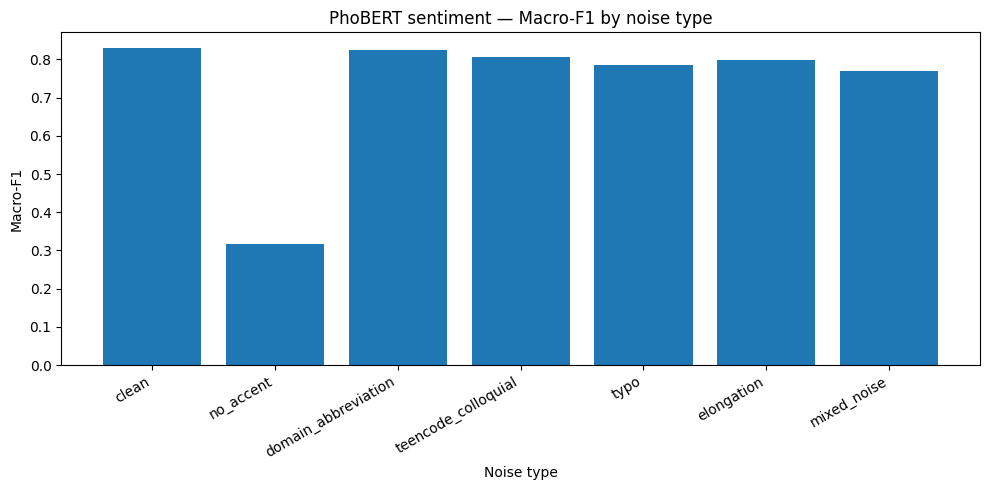

Saved: /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_by_noise_type_sentiment.png


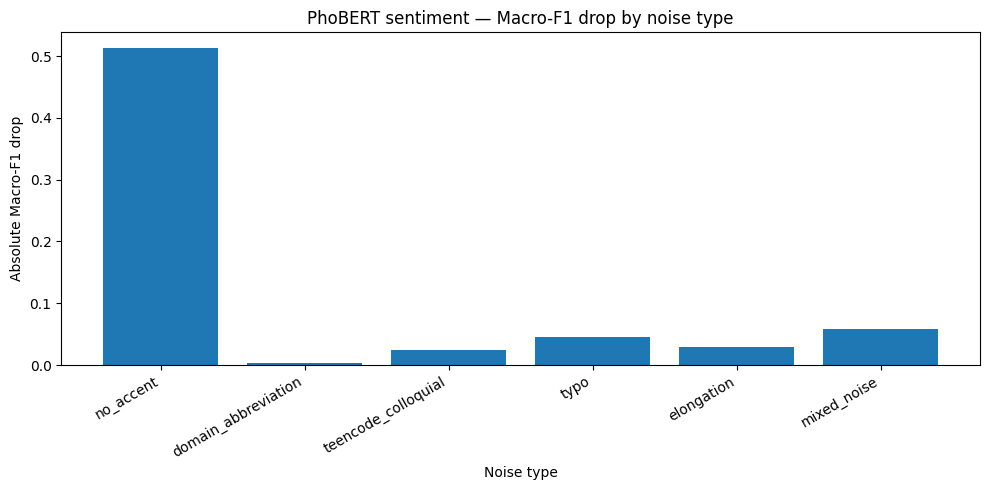

Saved: /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_drop_by_noise_type_sentiment.png


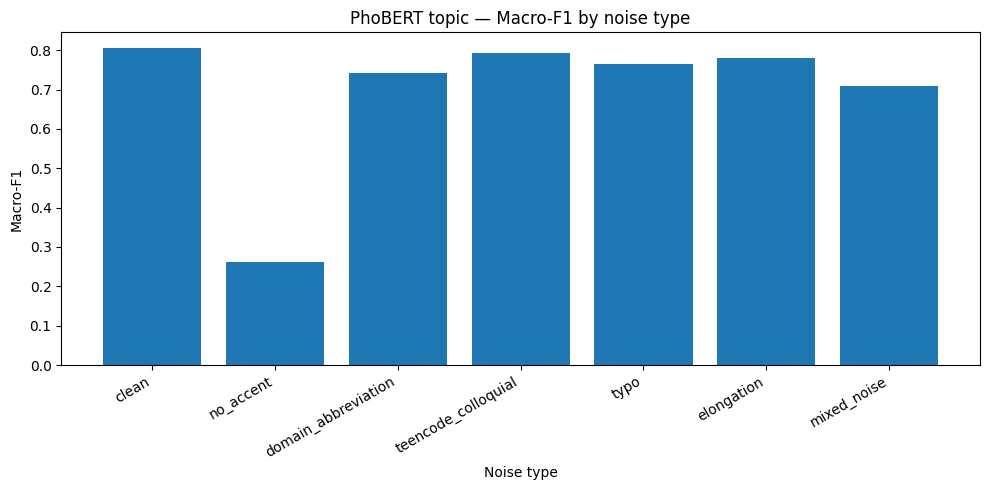

Saved: /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_by_noise_type_topic.png


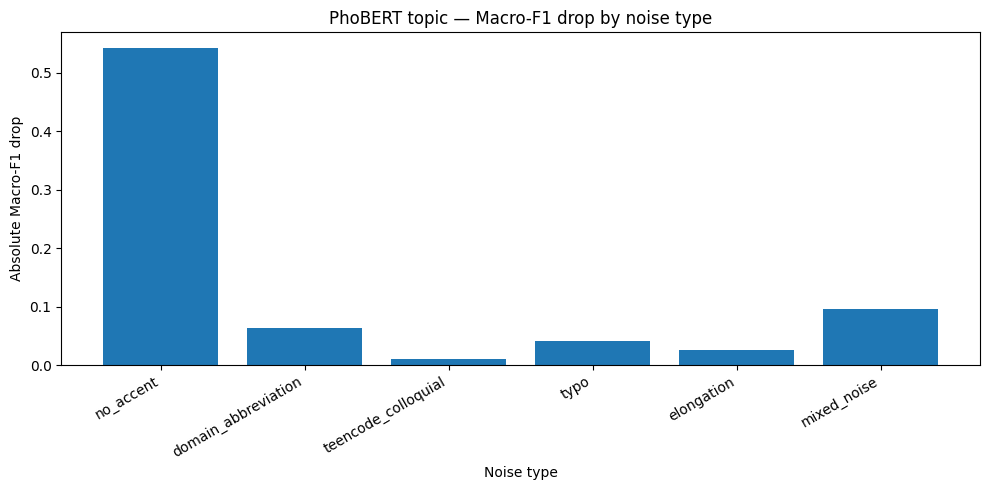

Saved: /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_drop_by_noise_type_topic.png


In [9]:
phobert_results_path = TABLES_DIR / "06b_phobert_noisy_evaluation_all.csv"
phobert_predictions_path = TABLES_DIR / "06b_phobert_predictions_light.csv"
phobert_reports_path = TABLES_DIR / "06b_phobert_classification_reports_all.csv"
phobert_drop_path = TABLES_DIR / "06b_phobert_robustness_drop_all.csv"
phobert_ranking_path = TABLES_DIR / "06b_phobert_robustness_ranking.csv"

phobert_results_df.to_csv(phobert_results_path, index=False, encoding="utf-8-sig")
phobert_predictions_light_df.to_csv(phobert_predictions_path, index=False, encoding="utf-8-sig")
phobert_classification_reports_df.to_csv(phobert_reports_path, index=False, encoding="utf-8-sig")
phobert_drop_df.to_csv(phobert_drop_path, index=False, encoding="utf-8-sig")
phobert_ranking_df.to_csv(phobert_ranking_path, index=False, encoding="utf-8-sig")

for task in ["sentiment", "topic"]:
    phobert_results_df[phobert_results_df["task"] == task].to_csv(
        TABLES_DIR / f"06b_phobert_noisy_evaluation_{task}.csv",
        index=False,
        encoding="utf-8-sig",
    )
    phobert_drop_df[phobert_drop_df["task"] == task].to_csv(
        TABLES_DIR / f"06b_phobert_robustness_drop_{task}.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Saved tables:")
for path in [
    phobert_results_path,
    phobert_predictions_path,
    phobert_reports_path,
    phobert_drop_path,
    phobert_ranking_path,
]:
    print("-", path)

# Figures
def plot_phobert_macro_f1(task: str):
    task_df = phobert_results_df[
        (phobert_results_df["task"] == task)
        & (phobert_results_df["evaluation_scope"] == "full")
    ].copy()

    order = [
        "clean",
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]
    order = [item for item in order if item in set(task_df["noise_type"])]

    task_df["noise_type"] = pd.Categorical(task_df["noise_type"], categories=order, ordered=True)
    task_df = task_df.sort_values("noise_type")

    plt.figure(figsize=(10, 5))
    plt.bar(task_df["noise_type"].astype(str), task_df["macro_f1"])
    plt.title(f"PhoBERT {task} — Macro-F1 by noise type")
    plt.xlabel("Noise type")
    plt.ylabel("Macro-F1")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    path = FIGURES_DIR / f"06b_phobert_macro_f1_by_noise_type_{task}.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


def plot_phobert_drop(task: str):
    task_df = phobert_drop_df[
        (phobert_drop_df["task"] == task)
        & (phobert_drop_df["evaluation_scope"] == "full")
    ].copy()

    order = [
        "no_accent",
        "domain_abbreviation",
        "teencode_colloquial",
        "typo",
        "elongation",
        "mixed_noise",
    ]
    order = [item for item in order if item in set(task_df["noise_type"])]

    task_df["noise_type"] = pd.Categorical(task_df["noise_type"], categories=order, ordered=True)
    task_df = task_df.sort_values("noise_type")

    plt.figure(figsize=(10, 5))
    plt.bar(task_df["noise_type"].astype(str), task_df["absolute_macro_f1_drop"])
    plt.title(f"PhoBERT {task} — Macro-F1 drop by noise type")
    plt.xlabel("Noise type")
    plt.ylabel("Absolute Macro-F1 drop")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    path = FIGURES_DIR / f"06b_phobert_macro_f1_drop_by_noise_type_{task}.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)


for task in ["sentiment", "topic"]:
    plot_phobert_macro_f1(task)
    plot_phobert_drop(task)


## 10. Generate Stage 6B report

In [10]:
def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return "_Empty table_"

    safe_df = df.copy()
    for col in safe_df.columns:
        if pd.api.types.is_float_dtype(safe_df[col]):
            safe_df[col] = safe_df[col].round(4)
        safe_df[col] = safe_df[col].astype(str)

    headers = safe_df.columns.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for _, row in safe_df.iterrows():
        lines.append("| " + " | ".join(row[col] for col in headers) + " |")
    return "\n".join(lines)


report_lines = []

report_lines.append("# PhoBERT Clean vs Noisy Evaluation Report\n")
report_lines.append(f"- Created at: `{datetime.now().isoformat(timespec='seconds')}`")
report_lines.append("- Stage: `06b_phobert_noisy_evaluation`")
report_lines.append(f"- Stage 3 model zip: `{STAGE3_ZIP}`")
report_lines.append(f"- Device: `{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}`")
report_lines.append("- Primary metric: `Macro-F1`")
report_lines.append("- No model is trained in this stage; fine-tuned PhoBERT checkpoints from Stage 3 are loaded.")
report_lines.append("- Clean/noisy test data is regenerated inside Kaggle from the Hugging Face parquet test split and Stage 4 rule configuration.\n")

report_lines.append("## Clean performance\n")
clean_perf = phobert_results_df[
    (phobert_results_df["noise_type"] == "clean")
    & (phobert_results_df["evaluation_scope"] == "full")
][[
    "task",
    "model_type",
    "model_name",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "num_eval_samples",
]]
report_lines.append(dataframe_to_markdown(clean_perf))
report_lines.append("\n")

report_lines.append("## Full noisy evaluation summary\n")
full_noisy = phobert_results_df[
    (phobert_results_df["noise_type"] != "clean")
    & (phobert_results_df["evaluation_scope"] == "full")
][[
    "task",
    "noise_type",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "num_eval_samples",
]]
report_lines.append(dataframe_to_markdown(full_noisy))
report_lines.append("\n")

report_lines.append("## Robustness drop summary\n")
drop_display = phobert_drop_df[
    phobert_drop_df["evaluation_scope"] == "full"
][[
    "task",
    "noise_type",
    "clean_macro_f1",
    "noisy_macro_f1",
    "absolute_macro_f1_drop",
    "relative_macro_f1_drop_pct",
]]
report_lines.append(dataframe_to_markdown(drop_display))
report_lines.append("\n")

report_lines.append("## Interpretation notes\n")
report_lines.append("- Positive drop means PhoBERT performs worse than on clean test data.")
report_lines.append("- Negative drop means the noisy variant happened to score higher than clean and should be interpreted cautiously.")
report_lines.append("- Changed-only results are available in CSV outputs for rule types that do not affect every row.")
report_lines.append("- Results should be merged with Stage 6A baseline results for final comparison.\n")

report_lines.append("## Limitations\n")
report_lines.append("- Noisy data is rule-generated and not fully human-validated.")
report_lines.append("- This notebook only evaluates PhoBERT. Baseline results are produced by Stage 6A.")
report_lines.append("- Detailed error examples are left for Stage 7.\n")

report_path = NOTES_DIR / "06b_phobert_noisy_evaluation_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved:", report_path)


Saved: /kaggle/working/stage6b_outputs/reports/notes/06b_phobert_noisy_evaluation_report.md


## 11. Package outputs

In [11]:
OUTPUT_ZIP = WORK_DIR / "stage6b_phobert_noisy_eval_outputs.zip"

if OUTPUT_ZIP.exists():
    OUTPUT_ZIP.unlink()

with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for file in OUTPUT_ROOT.rglob("*"):
        if file.is_file():
            z.write(file, file.relative_to(OUTPUT_ROOT))

print("Created:", OUTPUT_ZIP)
print("Size:", OUTPUT_ZIP.stat().st_size, "bytes")

expected_files = [
    TABLES_DIR / "06b_phobert_noisy_evaluation_all.csv",
    TABLES_DIR / "06b_phobert_robustness_drop_all.csv",
    TABLES_DIR / "06b_phobert_robustness_ranking.csv",
    TABLES_DIR / "06b_phobert_predictions_light.csv",
    NOTES_DIR / "06b_phobert_noisy_evaluation_report.md",
    FIGURES_DIR / "06b_phobert_macro_f1_by_noise_type_sentiment.png",
    FIGURES_DIR / "06b_phobert_macro_f1_by_noise_type_topic.png",
    FIGURES_DIR / "06b_phobert_macro_f1_drop_by_noise_type_sentiment.png",
    FIGURES_DIR / "06b_phobert_macro_f1_drop_by_noise_type_topic.png",
    OUTPUT_ZIP,
]

print("\nStage 6B output check:")
all_ok = True
for path in expected_files:
    exists = path.exists()
    all_ok = all_ok and exists
    print("[OK]     " if exists else "[MISSING]", path)

print("\nStage 6B completed:", all_ok)


Created: /kaggle/working/stage6b_phobert_noisy_eval_outputs.zip
Size: 667882 bytes

Stage 6B output check:
[OK]      /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_noisy_evaluation_all.csv
[OK]      /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_robustness_drop_all.csv
[OK]      /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_robustness_ranking.csv
[OK]      /kaggle/working/stage6b_outputs/reports/tables/06b_phobert_predictions_light.csv
[OK]      /kaggle/working/stage6b_outputs/reports/notes/06b_phobert_noisy_evaluation_report.md
[OK]      /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_by_noise_type_sentiment.png
[OK]      /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_by_noise_type_topic.png
[OK]      /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_drop_by_noise_type_sentiment.png
[OK]      /kaggle/working/stage6b_outputs/reports/figures/06b_phobert_macro_f1_drop_by_noise_type_topic.pn

## Download

Download:

```text
/kaggle/working/stage6b_phobert_noisy_eval_outputs.zip
```

Then extract the zip into your local project root and send these files for review:

```text
reports/tables/06b_phobert_noisy_evaluation_all.csv
reports/tables/06b_phobert_robustness_drop_all.csv
reports/tables/06b_phobert_robustness_ranking.csv
reports/notes/06b_phobert_noisy_evaluation_report.md
```
